<img src="../Decorative-Elements/Section-05/ADL-S05-Image-03-b.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../05-Applications/01-Tidal-Effects.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/03-Resonance-Effects-in-Planet.ipynb" target="_blank">Next</a>
</p>

In [ ]:
# Planet Packing

# 1. Definition:
#    - Planet packing refers to how planets are arranged in a 
#      planetary system such that they occupy available stable 
#      orbital space efficiently.
#    - A system is "dynamically packed" if adding another planet 
#      would make it unstable due to gravitational interactions.

# 2. Stability Constraints:
#    - Planets cannot be too close to each other; otherwise, 
#      mutual gravitational perturbations may lead to collisions 
#      or ejections.
#    - Orbital resonances (ratios of orbital periods) can either 
#      stabilize or destabilize neighboring planets.

# 3. Implications:
#    - Explains why some exoplanetary systems have tightly 
#      spaced planets (e.g., TRAPPIST-1).
#    - Helps predict where undiscovered planets might exist 
#      in gaps between known planets.
#    - Useful in simulations to test orbital stability and 
#      possible maximum number of planets.

# 4. Visualization Ideas:
#    - Draw planetary orbits with spacing to show "packed" vs 
#      "loose" systems.
#    - Highlight dynamically unstable regions where additional 
#      planets cannot survive.
#    - Use color or markers to indicate stability or resonance zones.

# 5. Applications:
#    - Exoplanet discovery: predict where planets could exist.
#    - N-body simulations: study evolution of planetary systems.
#    - Astrophysics education: illustrate orbital dynamics and 
#      gravitational interactions.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

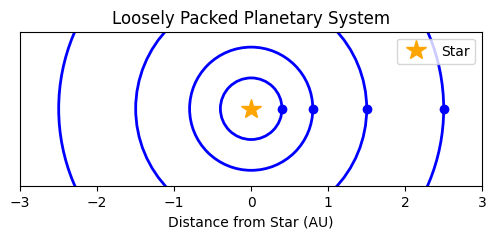

In [2]:
# Example: Loosely Packed System
# Star at center
star_pos = 0

# Planet semi-major axes (in arbitrary units, AU)
planets_loose = np.array([0.4, 0.8, 1.5, 2.5])  # loosely spaced

# Plot orbits
fig, ax = plt.subplots(figsize=(10,2))
for a in planets_loose:
    circle = plt.Circle((star_pos, 0), a, color='blue', fill=False, linewidth=2)
    ax.add_artist(circle)
    ax.plot(a, 0, 'o', color='blue')  # mark planet

ax.plot(star_pos, 0, '*', color='orange', markersize=15, label='Star')
ax.set_xlim(-3,3)
ax.set_ylim(-1,1)
ax.set_aspect('equal')
ax.set_yticks([])
ax.set_xlabel("Distance from Star (AU)")
ax.set_title("Loosely Packed Planetary System")
ax.legend()
plt.show()

In [ ]:
# Planets are plotted as blue circles representing orbits.
# Star is at the center (orange star).
# Planets are far apart, leaving empty orbital gaps → loosely packed.

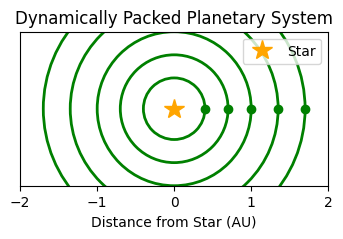

In [3]:
# Example: Dynamically Packed System
# Star at center
star_pos = 0

# Planet semi-major axes (in AU), packed closer
planets_packed = np.array([0.4, 0.7, 1.0, 1.35, 1.7])  # tightly spaced

# Plot orbits
fig, ax = plt.subplots(figsize=(10,2))
for a in planets_packed:
    circle = plt.Circle((star_pos, 0), a, color='green', fill=False, linewidth=2)
    ax.add_artist(circle)
    ax.plot(a, 0, 'o', color='green')  # mark planet

ax.plot(star_pos, 0, '*', color='orange', markersize=15, label='Star')
ax.set_xlim(-2,2)
ax.set_ylim(-1,1)
ax.set_aspect('equal')
ax.set_yticks([])
ax.set_xlabel("Distance from Star (AU)")
ax.set_title("Dynamically Packed Planetary System")
ax.legend()
plt.show()

In [ ]:
# Planets are closer together than in the previous cell.
# Orbits fill most of the stable orbital space → dynamically packed.
# Adding another planet in the gaps could destabilize the system → maximally packed.

In [4]:
# Function to check minimum spacing between planets (in AU)
def min_spacing(planets):
    planets_sorted = np.sort(planets)
    spacing = np.diff(planets_sorted)
    return spacing.min()

# Loosely packed system
planets_loose = np.array([0.4, 0.8, 1.5, 2.5])
min_spacing_loose = min_spacing(planets_loose)

# Packed system
planets_packed = np.array([0.4, 0.7, 1.0, 1.35, 1.7])
min_spacing_packed = min_spacing(planets_packed)

print(f"Minimum orbital spacing (loosely packed): {min_spacing_loose:.2f} AU")
print(f"Minimum orbital spacing (packed): {min_spacing_packed:.2f} AU")

# Stability interpretation
threshold = 0.25  # arbitrary threshold for "stable" spacing
print("\nStability check:")
for system, spacing in zip(['Loose','Packed'], [min_spacing_loose, min_spacing_packed]):
    if spacing >= threshold:
        print(f"{system} system: Likely stable")
    else:
        print(f"{system} system: Close to instability")

Minimum orbital spacing (loosely packed): 0.40 AU
Minimum orbital spacing (packed): 0.30 AU

Stability check:
Loose system: Likely stable
Packed system: Likely stable


In [ ]:
# Computes minimum spacing between consecutive planets.
# Uses a threshold to indicate whether the system is likely stable.
# Shows that packed systems have smaller spacing → near stability limit.

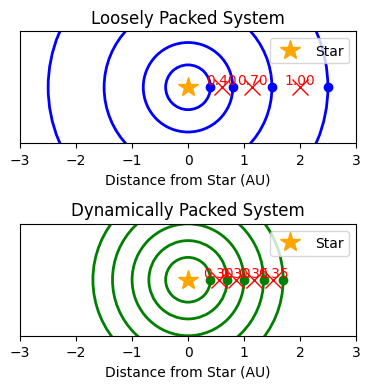

In [5]:
# Visualizing Gaps in Packed vs Loose Systems
# Systems
systems = {
    "Loosely Packed": np.array([0.4, 0.8, 1.5, 2.5]),
    "Dynamically Packed": np.array([0.4, 0.7, 1.0, 1.35, 1.7])
}

fig, axes = plt.subplots(2, 1, figsize=(10,4))

for ax, (name, planets) in zip(axes, systems.items()):
    ax.set_title(f"{name} System")
    ax.plot(0, 0, '*', color='orange', markersize=15, label='Star')
    
    # Plot planet orbits
    for a in planets:
        circle = plt.Circle((0,0), a, color='blue' if name=="Loosely Packed" else 'green', fill=False, linewidth=2)
        ax.add_artist(circle)
        ax.plot(a, 0, 'o', color='blue' if name=="Loosely Packed" else 'green')
    
    # Highlight gaps
    planets_sorted = np.sort(planets)
    for i in range(len(planets_sorted)-1):
        gap_center = (planets_sorted[i] + planets_sorted[i+1])/2
        gap_width = planets_sorted[i+1] - planets_sorted[i]
        ax.plot(gap_center, 0, 'x', color='red', markersize=12)
        ax.text(gap_center, 0.05, f"{gap_width:.2f}", color='red', ha='center')

    ax.set_xlim(-3,3)
    ax.set_ylim(-1,1)
    ax.set_aspect('equal')
    ax.set_yticks([])
    ax.set_xlabel("Distance from Star (AU)")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Planets plotted as circles, star at the center.
# Red X marks the center of gaps between planets.
# Gap width labeled → shows how much space is available for an extra planet.
# Loosely packed system → large gaps, easy to add a planet.
# Dynamically packed → tiny gaps, likely no additional planets can fit.

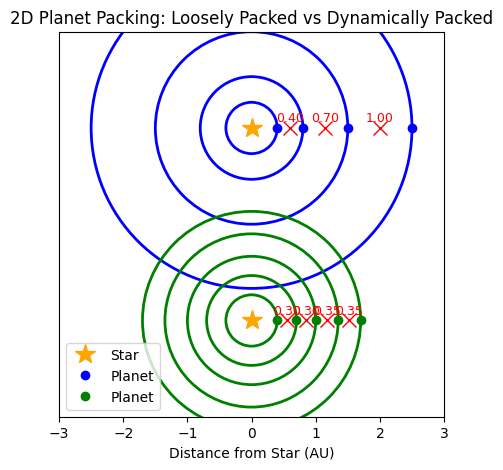

In [ ]:
# Planetary systems
systems = {
    "Loosely Packed": np.array([0.4, 0.8, 1.5, 2.5]),
    "Dynamically Packed": np.array([0.4, 0.7, 1.0, 1.35, 1.7])
}

# -----------------------------
# Plotting
# -----------------------------
fig, ax = plt.subplots(figsize=(10,5))

colors = {"Loosely Packed": "blue", "Dynamically Packed": "green"}
y_offsets = {"Loosely Packed": 1.5, "Dynamically Packed": -1.5}  # vertical separation

for name, planets in systems.items():
    y_off = y_offsets[name]
    # Star
    ax.plot(0, y_off, '*', color='orange', markersize=15, label='Star' if name=="Loosely Packed" else "")
    
    # Planet orbits
    for i, a in enumerate(planets):
        circle = plt.Circle((0, y_off), a, color=colors[name], fill=False, linewidth=2)
        ax.add_artist(circle)
        ax.plot(a, y_off, 'o', color=colors[name], label='Planet' if i==0 else "")
    
    # Gap centers
    planets_sorted = np.sort(planets)
    for i in range(len(planets_sorted)-1):
        gap_center = (planets_sorted[i] + planets_sorted[i+1])/2
        gap_width = planets_sorted[i+1] - planets_sorted[i]
        ax.plot(gap_center, y_off, 'x', color='red', markersize=10)
        ax.text(gap_center, y_off+0.1, f"{gap_width:.2f}", color='red', ha='center', fontsize=9)

# Labels and layout
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_yticks([])
ax.set_xlabel("Distance from Star (AU)")
ax.set_title("2D Planet Packing: Loosely Packed vs Dynamically Packed")
ax.legend()
plt.show()

In [ ]:
# Blue system → loosely packed; large gaps, extra planets can fit.
# Green system → dynamically packed; tiny gaps, nearly full.
# Red X → centers of gaps, numbers show width of orbital gaps.
# Orange star → central star.
# Visual intuition: you can see where new planets could fit and where a system is maximally packed.

In [ ]:
# Mutual Hill Radius and Minimum Spacing
# Physical constants (normalized)
M_star = 1.0       # Solar mass
M1, M2 = 1e-5, 2e-5  # Planet masses in solar masses
a1, a2 = 1.0, 1.1   # Semi-major axes in AU

# Mutual Hill radius formula
R_H = ((M1 + M2)/(3*M_star))**(1/3) * ((a1 + a2)/2)

# Minimum separation for stability (typically 3.5 - 4 mutual Hill radii)
k = 3.5
min_separation = k * R_H

print(f"Mutual Hill radius: {R_H:.5f} AU")
print(f"Minimum stable separation (k={k}): {min_separation:.5f} AU")
print(f"Actual separation: {a2 - a1:.5f} AU")

# Check stability
if (a2 - a1) > min_separation:
    print("Planets are likely stable")
else:
    print("Planets are too close – unstable configuration")

Mutual Hill radius: 0.02262 AU
Minimum stable separation (k=3.5): 0.07918 AU
Actual separation: 0.10000 AU
Planets are likely stable


In [ ]:
# Mutual Hill radius (R_H): region around planets where their gravity dominates over the star.
# k × R_H: empirical criterion from N-body simulations for long-term stability.
# Compare actual separation (a2-a1) with minimum required separation:
# If actual > k * R_H → system is likely stable.
# If actual < k * R_H → system may become dynamically unstable.

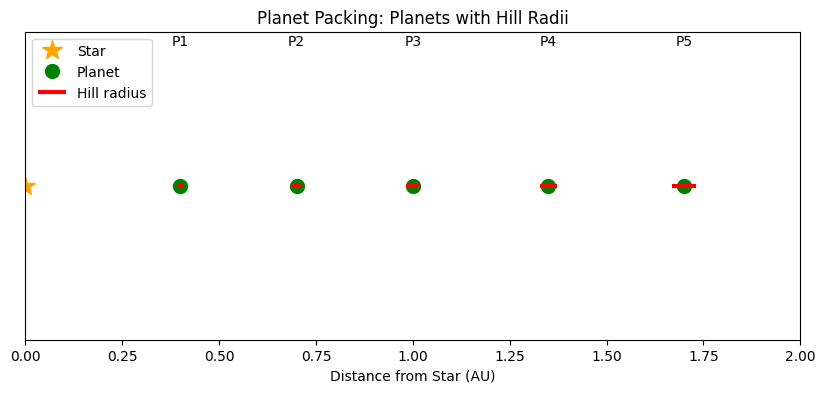

In [9]:
# visualize a fully packed system using mutual Hill radii, 
# view gaps and stability zones graphically.
# Star
M_star = 1.0  # solar masses
plt.figure(figsize=(10,4))

# Define planets: semi-major axes (AU) and masses (solar masses)
planets = [
    {"a": 0.4, "m": 1e-5},
    {"a": 0.7, "m": 2e-5},
    {"a": 1.0, "m": 1.5e-5},
    {"a": 1.35, "m": 1.2e-5},
    {"a": 1.7, "m": 2e-5}
]

# Plot star
plt.plot(0, 0, '*', color='orange', markersize=15, label='Star')

# Compute and plot Hill radii for each planet
for i, p in enumerate(planets):
    a = p["a"]
    m = p["m"]
    # Approximate Hill radius
    R_H = a * (m / (3*M_star))**(1/3)
    # Draw planet orbit
    plt.plot(a, 0, 'o', color='green', markersize=10)
    # Draw Hill sphere as a horizontal line for simplicity
    plt.hlines(0, a - R_H, a + R_H, color='red', linewidth=3)
    plt.text(a, 0.05, f"P{i+1}", ha='center', fontsize=10)

plt.xlabel("Distance from Star (AU)")
plt.title("Planet Packing: Planets with Hill Radii")
plt.yticks([])
plt.xlim(0, 2)
plt.legend(['Star', 'Planet', 'Hill radius'])
plt.show()

In [10]:
# Green dots → planets.
# Red horizontal lines → Hill radii of each planet, showing their “zones of influence.”
# Tightly packed system → Hill spheres are just touching but not overlapping, demonstrating dynamical packing.
# Star at 0 AU.

Maximum number of planets in range: 26
Planet semi-major axes (AU): [0.4   0.426 0.454 0.484 0.516 0.55  0.587 0.625 0.666 0.71  0.757 0.807
 0.86  0.917 0.977 1.041 1.11  1.183 1.261 1.344 1.433 1.527 1.628 1.735
 1.849 1.971]


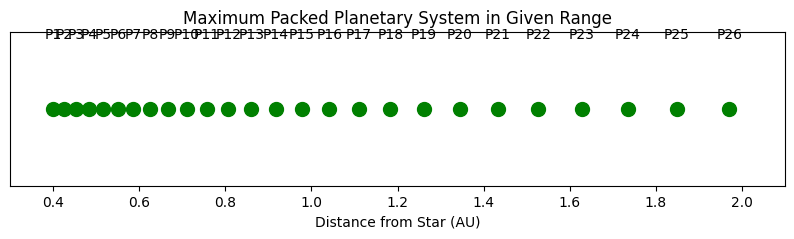

In [11]:
# how many planets you can fit in a given orbital range using mutual Hill radii spacing
# Star and planet properties
M_star = 1.0        # Solar mass
m_planet = 1e-5     # Planet mass (all equal)
k = 3.5             # Separation in mutual Hill radii for stability

# Orbital range
a_inner = 0.4       # AU
a_outer = 2.0       # AU

# Function to compute mutual Hill radius for consecutive planets
def mutual_hill(a1, a2, m, M_star):
    return ((2*m)/(3*M_star))**(1/3) * ((a1 + a2)/2)

# Iteratively place planets
a_planets = [a_inner]
while True:
    a_prev = a_planets[-1]
    # Approximate next semi-major axis
    R_H = a_prev * (2*m_planet/(3*M_star))**(1/3)
    a_next = a_prev + k*R_H
    if a_next > a_outer:
        break
    a_planets.append(a_next)

print("Maximum number of planets in range:", len(a_planets))
print("Planet semi-major axes (AU):", np.round(a_planets, 3))

# Visualize
plt.figure(figsize=(10,2))
plt.plot(0, 0, '*', color='orange', markersize=15, label='Star')
for i, a in enumerate(a_planets):
    plt.plot(a, 0, 'o', color='green', markersize=10)
    plt.text(a, 0.05, f"P{i+1}", ha='center', fontsize=10)
plt.xlabel("Distance from Star (AU)")
plt.yticks([])
plt.title("Maximum Packed Planetary System in Given Range")
plt.xlim(a_inner-0.1, a_outer+0.1)
plt.show()

In [ ]:
# Applications:
# Studying extrasolar systems (like TRAPPIST-1 or Kepler multi-planet systems).
# Understanding gaps in planetary systems (where additional planets might exist).
# Designing stable synthetic planetary systems for simulations.

<p style="display: flex; justify-content: space-between;">
  <a href="../05-Applications/01-Tidal-Effects.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/03-Resonance-Effects-in-Planet.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-05-02.gif">